In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *

## Item 0

### item 0.1

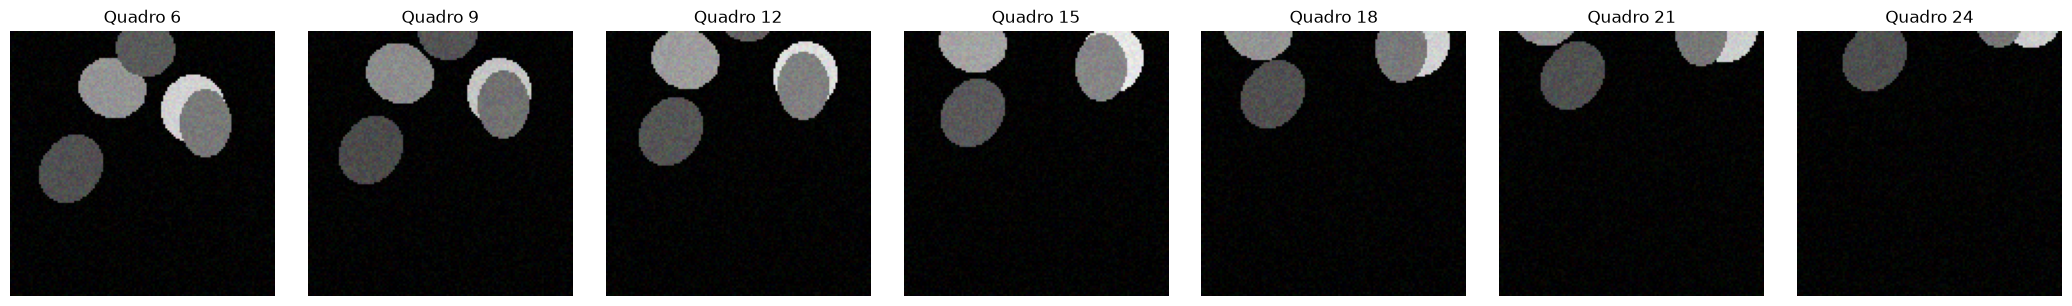

In [2]:
frames, gt = gerador(num_objetos=5, velocidade_tipica=3.0)
visualizar_trajetoria(frames, inicio=5, fim=25, passo=3)

In [3]:
print("Quantidade de quadros gerados:", len(frames))

Quantidade de quadros gerados: 45


### item 0.3

In [4]:
# 1. Caso Perfeito (GT e Rastreador são idênticos)
gt_teste = [[1, 1, 10, 10, 20, 20], [2, 1, 12, 12, 20, 20]]
tr_perfeito = [[1, 1, 10, 10, 20, 20], [2, 1, 12, 12, 20, 20]]

# 2. Caso com Troca de ID (Rastreador muda ID no meio do caminho)
tr_switch = [[1, 1, 10, 10, 20, 20], [2, 2, 12, 12, 20, 20]]

# 3. Caso sem detecções
tr_vazio = []

print("1. IDF1 Perfeito (Esperado 1.0):", calcular_idf1(gt_teste, tr_perfeito))
print("2. IDF1 com ID Switch (Esperado 0.5):", calcular_idf1(gt_teste, tr_switch))
print("3. IDF1 Vazio (Esperado 0.0):", calcular_idf1(gt_teste, tr_vazio))

1. IDF1 Perfeito (Esperado 1.0): 1.0
2. IDF1 com ID Switch (Esperado 0.5): 0.5
3. IDF1 Vazio (Esperado 0.0): 0.0


In [ ]:
# 1. Caso Perfeito (Sem trocas, acerto de 100%)
gt_teste = [
    [1, 10, 10, 10, 20, 20],
    [2, 10, 12, 12, 20, 20],
    [3, 10, 14, 14, 20, 20]
]
tr_perfeito = [
    [1, 10, 10, 10, 20, 20],
    [2, 10, 12, 12, 20, 20],
    [3, 10, 14, 14, 20, 20]
]

# 2. Caso com 1 ID Switch (Troca de ID 10 para 99 no frame 2)
tr_switch = [
    [1, 10, 10, 10, 20, 20],
    [2, 99, 12, 12, 20, 20],
    [3, 99, 14, 14, 20, 20]
]

# 3. Caso Vazio (Rastreador não detectou nada)
tr_vazio = []

print("=== VALIDAÇÃO DAS MÉTRICAS ===")
print("1. Caso Perfeito   -> IDF1:", calcular_idf1(gt_teste, tr_perfeito), "| IDSW:", calcular_idsw(gt_teste, tr_perfeito))
print("2. Caso ID Switch  -> IDF1:", round(calcular_idf1(gt_teste, tr_switch), 2), "| IDSW:", calcular_idsw(gt_teste, tr_switch))
print("3. Caso Vazio      -> IDF1:", calcular_idf1(gt_teste, tr_vazio), "| IDSW:", calcular_idsw(gt_teste, tr_vazio))

=== VALIDAÇÃO DAS MÉTRICAS ===
1. Caso Perfeito   -> IDF1: 1.0 | IDSW: 0
2. Caso ID Switch  -> IDF1: 0.67 | IDSW: 1
3. Caso Vazio      -> IDF1: 0.0 | IDSW: 0


Pipelinae completo

In [ ]:
frames, gt = gerador(num_objetos=8, velocidade_tipica=2.5, num_frames=45)

# Parte 2 que falta 
deteccoes = simular_detector(gt, p_drop=0.1, noise_std=2.0, fp_per_frame=0.5)

tracker = IoUTracker(iou_threshold=0.3, max_lost=3)
predicoes_rastreador = []

# Processa quadro a quadro
frames_ids = np.unique([d[0] for d in deteccoes]).astype(int)
for f in sorted(frames_ids):
    dets_f = [d[2:] for d in deteccoes if d[0] == f]  # Pega [x, y, w, h, conf]
    res_f = tracker.update(f, dets_f)
    predicoes_rastreador.extend(res_f)

idf1 = calcular_idf1(gt, predicoes_rastreador)
idsw = calcular_idsw(gt, predicoes_rastreador)

print("=== RESULTADOS DO PIPELINE (PARTE 0) ===")
print(f"IDF1 Score: {idf1 * 100:.2f}%")
print(f"ID Switches (IDSW): {idsw}")